In [1]:
import pandas
from datetime import datetime
import calendar
import re
from lib.Presenter import Presenter

'''
This script handles enforcement of standard formats within the dataset.
'''

class Standardizer(Presenter):
    def __init__(self, _df, _outputDf):
        self.df = _df
        self.outputDF = _outputDf

    def StandardizeAll(self):
        '''
        Batch function used to execute all standardization processes with one call.
        '''
        self.StandardizeHealthBoard()
        self.StandardizeSpecialty()
        self.StandardizeOutcome()
        self.StandardizeFollowUp()
        self.StandardizeDatesInColumn("Appointment Date")
        self.StandardizeDatesInColumn("Date of Birth")
        self.StandardizeNames()
        self.StandardizePostCodes()

    def StandardizeNames(self):
        """
        Standardizes patient names within the dataset to the following format: 'Fname Lname'
        """
        print("=" * 30)
        print("... Standardizing patient names ... ", end="")
        affectedCount = 0
        for i, name in enumerate(self.df["Patient Name"]):

            if pandas.isna(name):
                self.outputDF.loc[i, "Patient Name"] = pandas.NA
                affectedCount += 1
                continue

            nameParts = name.split(", ")
            new_name = name
            if len(nameParts) > 1:
                affectedCount += 1
                new_name = f"{nameParts[1]} {nameParts[0]}"

            self.outputDF.loc[i, "Patient Name"] = new_name
        self.PresentAffectedCount(affectedCount)


    def StandardizePostCodes(self):
        """
        Ensures every letter in post codes value is capitalized.
        e.g. 'g22 7qt' -> 'G22 7QT'
        """
        print("=" * 30)
        print("... Standardizing post codes ... ", end="")
        affectedCount = 0
        for i, code in enumerate(self.df["Post Code"]):
            if pandas.isna(code):
                self.outputDF.loc[i, "Post Code"] = pandas.NA
                affectedCount += 1
                continue

            if re.search("[a-z]", code):
                affectedCount += 1

            newCode = code.upper()
            self.outputDF.loc[i, "Post Code"] = newCode
        self.PresentAffectedCount(affectedCount)


    def StandardizeHealthBoard(self):
        _map = {
            "nhs": "NHS",
            "and": "&",
        }

        print("=" * 30)
        print(f"... Standardizing Health Board ... ", end="")
        affectedCount = 0
        for i, val in enumerate(self.df["Health Board"]):
            valParts = val.split(" ")
            result = []
            for word in valParts:
                if word.lower() in _map.keys():
                    result.append(_map[word.lower()])
                    continue

                if (len(word) > 3):
                    result.append(word.title())
                else:
                    result.append(word)


            affectedCount += 1
            if result == valParts:
                affectedCount -= 1 
            
            self.outputDF.loc[i, "Health Board"] = " ".join(result)

        self.PresentAffectedCount(affectedCount)

            
    def StandardizeSpecialty(self):
        _map = {
            "nhs": "NHS",
            "and": "&",
            "ent": "ENT"
        }

        print("=" * 30)
        print(f"... Standardizing Specialty ... ", end="")
        affectedCount = 0
        for i, val in enumerate(self.df["Specialty"]):
            ValParts = val.split(" ")
            result = []

            for word in ValParts:
                if word.lower() in _map.keys():
                    result.append(_map[word.lower()])
                else:
                    result.append(word.title())

            affectedCount += 1
            if ValParts == result:
                affectedCount -= 1
            
            self.outputDF.loc[i, "Specialty"] = " ".join(result)

        self.PresentAffectedCount(affectedCount)


    def StandardizeOutcome(self):
        _map = {
            "dna": "DNA",
            "cbp": "CBP",
            "cbh": "cbh",
            "cancelled by patient": "CBP",
            "cancelled by hospital": "CBH",
            "attended": "A",
            "did not attend": "DNA"
        }

        print("=" * 30)
        print(f"... Standardizing Outcome records ... ", end="")
        affectedCount = 0

        for i, val in enumerate(self.df["Outcome"]):
            result = ""

            if isinstance(val, str) and val.lower() in _map.keys():
                result = _map[val.lower()]

            affectedCount += 1
            if result == val:
                affectedCount -= 1
        
            self.outputDF.loc[i, "Outcome"] = result

        self.PresentAffectedCount(affectedCount)


    def StandardizeFollowUp(self):
        _map = {
            "1": 1,
            "0": 0,
            "true": 1,
            "false": 0,
            "yes": 1,
            "no": 0,
            "n": 0,
            "y": 1
        }

        print("=" * 30)
        print(f"... Standardizing Follow Up Required ... ", end="")
        affectedCount = 0

        for i, val in enumerate(self.df["Follow Up Required"]):
            result = 0

            if pandas.isna(val):
                result = 0

            elif isinstance(val, str):

                if val.lower() in _map.keys():
                    result = _map[val.lower()]
                
            affectedCount += 1
            if str(val) == str(result):
                affectedCount -= 1
            
            self.outputDF.loc[i, "Follow Up Required"] = result
        
        self.PresentAffectedCount(affectedCount)


    def StandardizeDatesInColumn(self, col):
        """
        Standardizes all date values to the following format: YYYY-mm-dd.
        Impossible dates are rolled back to the last possible day to avoid data loss.
        """
        print("=" * 30)
        print(f"... Standardizing {col} dates ... ", end="")
        affectedCount = 0
        for i, dob in enumerate(self.df[col]):
            
            if isinstance(dob, str) and len(dob) > 0: # date exists
                dobParts = dob.split("/") if "/" in dob else dob.split("-")

                if len(dobParts[0]) == 4: # date has YYYY-mm-dd format
                    dobParts.reverse()
    
                if dobParts[1].isalpha(): # Normalize months
                    dobParts[1] = datetime.strptime(dobParts[1], "%b").strftime("%m")
    
                if len(dobParts[2]) < 4: # Normalize years
                    dobParts[2] = f'19{dobParts[2]}' if int(dobParts[2]) > 26 else f'20{dobParts[2]}'
                    
                # Roll back impossible dates
                max_day = calendar.monthrange(int(dobParts[2]), int(dobParts[1]))[1]
                if int(dobParts[0]) > int(max_day):
                    dobParts[0] = max_day
    
                d = datetime.strptime(f"{dobParts[0]}-{dobParts[1]}-{dobParts[2]}", '%d-%m-%Y')

                if str(d.date()) == dob:
                    affectedCount -= 1

                self.outputDF.loc[i, col] = d

            else: # date is null
                self.outputDF.loc[i, col] = pandas.NaT

            affectedCount += 1
        
        self.PresentAffectedCount(affectedCount)

In [2]:
import pandas
from lib.Presenter import Presenter

'''
This script handles all the sampling of the dataset.
'''

class Sampler(Presenter):
    def __init__(self, _df, _outputDf):
        self.df = _df
        self.outputDF = _outputDf

    def SampleProblematicValues(self):
        '''
        Iterates over each field seeking incorrectly formatted data as outlined in the "About the Dataset" table.
        Matches are catalogued and the catalogue is presented via a print() statement.
        '''

        samples = {x: [] for x in self.df.columns}

        for col in self.df.columns:
            '''
            Column names are inconsistent at this point and thus are subject to change.
            Due to that, they're identified by their index which won't mutate.
            ''' 
            colIndex = self.df.columns.get_loc(col)
            colVals = self.df[col]

            if colIndex == 0: # Patient ID
                samples[col] = colVals[colVals.astype(str).str.len() != 6].values

            elif colIndex == 1: # Patient Name
                samples[col] = colVals[colVals.astype(str).str.contains(",")].values

            elif colIndex == 2: # Date of Birth
                samples[col] = colVals[colVals.astype(str).str.contains("-")].values

            elif colIndex == 3: # Email Address
                samples[col] = colVals[pandas.isna(colVals)].values

            elif colIndex == 4: # Phone
                samples[col] = colVals[colVals.astype(str).str.len() != 10].values

            elif colIndex == 5: # Post Code
                samples[col] = colVals[colVals.astype(str).str.contains(r'[a-z]')].values

            elif colIndex == 6: # Health Board
                samples[col] = colVals[colVals.astype(str).str.contains("nhs")].values

            elif colIndex == 7: # Specialty
                samples[col] = colVals[colVals.astype(str).str.match(r'^[a-z]')].values

            elif colIndex == 8: # Appointment Date
                samples[col] = colVals[colVals.astype(str).str.match("-")].values

            elif colIndex == 9: # Wait Time Days
                samples[col] = list(colVals[colVals.isna()].values)

            elif colIndex == 10: # Outcome
                samples[col] = colVals[colVals.astype(str).str.len() > 3].values

            elif colIndex == 11: # Duration Minutes
                samples[col] = colVals[colVals.isna()].values

            elif colIndex == 12: # Follow Up Required 
                samples[col] = colVals[colVals.astype(str).str.match("([a-z]|[A-Z])")].values

            elif colIndex == 13: # Satisfaction Score
                samples[col] = colVals[colVals.astype(str).str.contains(r"\.")].values

            else: # Cost
                samples[col] = colVals[colVals.astype(str).str.contains("£")].values

        for key, sample in samples.items():
            if len(sample) > 0:
                print(f"... Sample for the column {key} ... {sample[0]}")

In [3]:

import pandas
from lib.Presenter import Presenter
import re

'''
This script handles cleaning of incorrect values within the dataset.
This includes pruning, casting, and enforcement of custom rules.
'''


class Cleaner(Presenter):
    def __init__(self, _df, _outputDf):
        self.df = _df
        self.outputDF = _outputDf

    def CleanAll(self):
        self.CleanCost()
        self.CleanDuration()
        self.CleanSatisfactionScore()
        self.CleanWaitTime()

    def CleanCost(self):
        '''
        Wrong values in this column include symbols and characters.
        Pound symbols and currency codes are stripped. Nulls are replaced
        with 0s.
        '''
        print("... Cleaning Cost column ... ", end="")
        affectedCount = 0
        for i, val in enumerate(self.df["Cost"]):
            new_val = ""
            if pandas.isna(val):
                val = float(0.0)
                affectedCount += 1

            elif "£" in val:
                val = val.replace("£", "")
                affectedCount +=1

            elif "GBP" in val:
                val = val.replace("GBP", "")
                affectedCount +=1

            new_val = float(val)
            self.outputDF.loc[i, "Cost"] = float(new_val)
        self.PresentAffectedCount(affectedCount)

    def CleanSatisfactionScore(self):
        '''
        Wrong values in this column are either out of range, null, or
        decimal. Decimals are rounded to the nearest integer. Out of
        range values are capped at 5. 
        '''
        print("... Cleaning Satisfaction Score column ... ", end="")
        affectedCount = 0
        for i, val in enumerate(self.df["Satisfaction Score"]):
            if pandas.isna(val):
                self.outputDF.loc[i, "Satisfaction Score"] = 0
                affectedCount += 1
                continue

            if re.search(r"^[1-5]$", val):
                self.outputDF.loc[i, "Satisfaction Score"] = int(val)
                continue # value is correct

            affectedCount += 1
            if "." in val:
                val = int(round(float(val)))

            new_val = int(val)

            if new_val > 5:
                new_val = 5

            self.outputDF.loc[i, "Satisfaction Score"] = new_val

        self.PresentAffectedCount(affectedCount)

    def CleanDuration(self):
        '''
        Wrong values in this column are null. Nulls are converted to 0.
        '''
        print("... Cleaning Duration Minutes column ... ", end="")
        affectedCount = 0
        for i, val in enumerate(self.df["Duration Minutes"]):
            new_val = ""

            if pandas.isna(val):
                affectedCount += 1
                val = 0

            new_val = int(val)
            self.outputDF.loc[i, "Duration Minutes"] = new_val
        self.PresentAffectedCount(affectedCount)


    def CleanWaitTime(self):
        '''
        Wrong values in this column are either null or less than 0.
        Since Wait Time Days column is of type integer, nulls are converted to 0.
        Negative values are assumed to be clerical errors and inverted to positive values.
        '''

        print("... Cleaning Wait Time Days column ... ", end="")
        affectedCount = 0
        for i, val in enumerate(self.df["Wait Time Days"]):
            new_val = ""

            if pandas.isna(val) or (isinstance(val, str) and val.isalpha()):
                val = 0
                affectedCount += 1

            new_val = int(val)
            if new_val < 0:
                new_val = -new_val
                affectedCount += 1

            self.outputDF.loc[i, "Wait Time Days"] = new_val

        self.PresentAffectedCount(affectedCount)

In [4]:
import pandas


class Presenter:
    '''
    This class presents the results of various processes.
    Presenting means to print() them in an organized way.
    '''

    def __init__(self, _df, _outputDF):
        self.df = _df
        self.outputDF = _outputDF
        pass

    def PresentAffectedCount(self, count):
        print(f"Affected {count} records.")
    
    def PresentMissingValuesPerColumn(self):
        for col in self.df.columns:
            missingValues = 0
            print(f"... Analyzing column {col} ...", end="")
            for i, row in self.df.iterrows():
                if pandas.isna(row[col]):
                    missingValues += 1
            print(f" missing {missingValues} values.")
        print ("="*30)

In [5]:
from lib.Presenter import Presenter
import pandas




class Pruner(Presenter):
    '''
    This class prunes redundant records. Most notably direct and indirect duplicates.
    '''

    def __init__(self, df, outputDF):
        self.df = df
        self.outputDF = outputDF
    
    def PruneAllDuplicates(self):
        '''
        Drops all duplicate and near-duplicate records.
        '''

        print("="*30)
        print("... Removing exact duplicates ... ", end="")
        self.PresentAffectedCount(self.GetDuplicatesCount())
        self.outputDF = self.outputDF.drop_duplicates() # Drop exact duplicates

        print("... Removing near duplicates ... ", end="")
        
        drop_records = self.GetNearDuplicates() # Get near duplicates
        self.PresentAffectedCount(len(drop_records))

        self.outputDF = self.outputDF.drop(drop_records) # & drop them
        return self.outputDF


    def GetDuplicatesCount(self):
        count = 0
        for i, (_, row1) in enumerate(self.outputDF.iterrows()):
            for j, (_, row2) in enumerate(self.outputDF.iterrows()):
                if i == j: # Avoids comparing a record to itself
                    continue

                if row1.equals(row2):
                    count += 1

        return count

    def GetNearDuplicates(self):
        '''
        Get the indexes of all near duplicates and return them.
        Near duplicates will differ in Wait Time Days. One record
        will always differ by 1 from another. This looks like a
        clerical error - An administrator readding the same record
        the next day. As such, the record with the lower Wait Time
        Days value will be pruned. 
        '''
        drop_records = []
        affectedCount = 0
        for i, (_, row1) in enumerate(self.outputDF.iterrows()):
            for j, (_, row2) in enumerate(self.outputDF.iterrows()):    
                if i == j:
                    continue        
                if self.IsNearMatch(row1, row2):
                    affectedCount += 1
                    if row1["Wait Time Days"] > row2["Wait Time Days"]:
                        drop_records.append(j)
                    else:
                        drop_records.append(i)
        return drop_records


    def IsNearMatch(self, row1, row2):
        '''
        A near duplicate is a record that shares the same specialty on the same date.
        While it is possible for a patient to have multiple appointments on
        the same day, realistically, you could only book one per specialty per day.
        '''
        if pandas.isna(row1["Patient ID"]) or pandas.isna(row2["Patient ID"]):
            return False

        if (row1["Patient ID"] == row2["Patient ID"] 
            and row1["Appointment Date"] == row2["Appointment Date"]
            and row1["Specialty"] == row2["Specialty"]):
            return True
        return False

In [6]:
import matplotlib.pyplot as plt

class Visualizer:
    '''
    This class visualizes the dataset using matplotlib.
    '''

    def __init__(self, df):
        self.df = df


    def VisualizeWaitTimeDistributionOverall(self):
        plt.figure()
        plt.hist(self.df["Wait Time Days"], bins=20)
        plt.title("Wait Times Distribution Overall")
        plt.figtext(
            x=0.2,
            y=0.5,
            s= """ 
            This chart presents the wait time distribution overall. It provides a
            big-picture overview of staff availability and may prove useful to 
            health board management in onboarding new staff.
            """,
            )
        plt.xlabel("Wait Time (days)")
        plt.ylabel("Number of Appointments")
        plt.show()

    def VisualizeWaitTimeDistributionByBoard(self):

        boards = self.df["Health Board"].unique()

        for board in boards:
            plt.figure()
            subset = self.df[self.df["Health Board"] == board]

            plt.hist(subset["Wait Time Days"], bins=20, alpha=0.5, label=board)

            plt.title(f"Wait Time Distribution in {board}")
            plt.figtext(
            x=0.2,
            y=0.5,
            s= """ 
            This chart is a more fine-grained version of the previous one. It breaks
            down wait time distribution by each unique health board. It provides a
            big-picture overview of staff availability in each health board, allowing
            management to reallocate existing staff in accordance with the demand.

            To increase readability and prevent overlapping records, each health board
            is shown separately.
            """,
            )
            plt.xlabel("Wait Time (days)")
            plt.ylabel("Number of Appointments")
            plt.legend()

            plt.show()

    def VisualizeDnaRatesBySpecialty(self):
        specialties = self.df["Specialty"].unique() # Get all specialties

        plt.figure()

        for specialty in specialties: 
            #subset = self.df[self.df["Specialty"] == specialty] # 
#
            #subset = subset[subset["Outcome"] == "DNA"]
            dna_counts = self.df[self.df["Outcome"] == "DNA"]["Specialty"].value_counts()
            plt.bar(dna_counts.index, dna_counts.values)

        plt.title("DNA (did not attend) Rates by Specialty")
        plt.figtext(
            x=0.2,
            y=0.5,
            s= """ 
            This chart presents the number of DNA records by each unique specialty.
            It may help health service identify which specialty sees the least
            patients, and develop a solution to the problem - e.g. Fees for
            not attending an appointment with a specialty who gets the most DNAs.
            """,
            )
        plt.xlabel("Specialty")
        plt.xticks(rotation=90)
        plt.ylabel("Number of DNAs")
        plt.show()

    def VisualizeSatisfactionScoreDistributionBySpecialty(self):
        specialties = self.df["Specialty"].unique()

        for specialty in specialties:
            plt.figure()
            subset = self.df[self.df["Specialty"] == specialty] # grab all records of specialty
            subset = subset[subset["Satisfaction Score"] != 0] # prune records where satisfaction score == 0

            plt.hist(subset["Satisfaction Score"], bins=20, alpha=0.5, label=specialty)
            plt.figtext(
            x=0.2,
            y=0.5,
            s= """ 
            This chart shows the satisfaction score distribution by each unique specialty.
            To avoid overlapping bars and vastly increase readability, each specialty is
            presented separately. This visualization may help health service identify
            specialties who fail to meet patient's needs, and conversly, those who do it very 
            well. This could lead to actions such as reallocation of resources to the
            specialties who need them most.
            """,
            )

            plt.title("Satisfaction Score by Specialty")
            plt.xlabel("Satisfaction Score")
            plt.ylabel("Number of Occurences")
            plt.legend()
            plt.show()

    
    def VisualiseRelationshipBetweenWaitTimeAndConsultationDuration(self):

        filtered = self.df[
            (self.df["Wait Time Days"] != 0) &
            (self.df["Duration Minutes"] != 0)
        ]
        plt.figure()
        plt.scatter(filtered["Wait Time Days"], filtered["Duration Minutes"])
        
        plt.title("Corelation Between Wait Time (days) and Appointment Duration (minutes)")
        plt.figtext(
            x=0.2,
            y=0.5,
            s= """ 
            This chart shows the corelation between wait time and appointment duration.
            Each dot represents a unique record. It matters because it could reveal important trends
            in corelation between longer wait times and appointment duration.
            The chart shows that no such corelation exists. Appoinment duration is not corelated to the
            wait time at all.""",
        )
        plt.xlabel("Wait Time (days)")
        plt.ylabel("Appointment Duration (minutes)")
        plt.show()

# Public Health Scotland Data Analysis

### Task 1: Data Cleaning and Preparation
#### 1.1. Preliminary qualitative data summary
Problematic values are chosen in accordance with the "About the Dataset" table provided. 
To read the problematic dataset reliably, a dtype object of all-strings is applied to the input data frame object; This ensures that the unstandardized values can be read and evaluated without errors. A target dtype object is defined and applied to the output data frame object. This output data frame object is populated with corrected values along the duration of the process, and a "output.csv" file is generated at the end of the process using that object.

In [7]:
'''
This script defines two separate DataFrame objects; df and outputDf, and
two separate data type schemas; SAFE_MAP and CORRECTED_MAP.

SAFE_MAP is used within the df object's creator to read the csv file provided.
It casts every column to string for safety due to the fact that the csv data is messy.

CORRECTED_MAP is the target map applied to the OutpuDF object. In it, every column
is given its target type. outputDF is populated after each cleaning step, and at
the end of the process, it is saved to output.csv.
'''

### ========================================
### Constants
### ========================================

INPUT_FILE = "UI108006_scottish_health_dataset.csv"
OUTPUT_FILE = "output.csv"

SAFE_MAP = {
    "Patient_ID": str,
    "patient_name": str,
    "Email Address": str,
    "Phone": str,
    "post_code": str,
    "Health Board": str,
    "SPECIALTY": str,
    "Wait_Time_Days": str,
    "Outcome": str,
    "Duration (mins)": str,
    "Cost": str,
    "satisfaction_score": str
}

CORRECTED_MAP = {
    "Patient ID": pandas.Series(dtype="string"),
    "Patient Name": pandas.Series(dtype="string"),
    "Date of Birth": pandas.Series(dtype="datetime64[ns]"),
    "Email Address": pandas.Series(dtype="string"),
    "Phone": pandas.Series(dtype="string"),  # better than int for phone numbers
    "Post Code": pandas.Series(dtype="string"),
    "Health Board": pandas.Series(dtype="string"),
    "Specialty": pandas.Series(dtype="string"),
    "Appointment Date": pandas.Series(dtype="datetime64[ns]"),
    "Wait Time Days": pandas.Series(dtype="int"),
    "Outcome": pandas.Series(dtype="string"),
    "Duration Minutes": pandas.Series(dtype="int"),
    "Follow Up Required": pandas.Series(dtype="bool"),
    "Satisfaction Score": pandas.Series(dtype="int"),
    "Cost": pandas.Series(dtype="float")
}

### ========================================
### Initialization
### ========================================

# Load csv into a dataframe object
df = pandas.read_csv(INPUT_FILE, 
                     dtype={
                     "Patient_ID": str,
                     "patient_name": str,
                     "Email Address": str,
                     "Phone": str,
                     "post_code": str,
                     "Health Board": str,
                     "SPECIALTY": str,
                     "Wait_Time_Days": str,
                     "Outcome": str,
                     "Duration (mins)": str,
                     "Cost": str,
                     "satisfaction_score": str})

# Rename columns within the dataframe object to target names.
df = df.rename(columns={
              "Patient_ID": "Patient ID",
              "patient_name": "Patient Name",
              "post_code": "Post Code",
              "SPECIALTY": "Specialty",
              "Wait_Time_Days": "Wait Time Days",
              "satisfaction_score": "Satisfaction Score",
              "appointment_date": "Appointment Date",
              "Duration (mins)": "Duration Minutes"})


# Target Dataframe object where all data is saved after cleaning
outputDF = pandas.DataFrame(CORRECTED_MAP)


cleaner = Cleaner(df, outputDF)
standardizer = Standardizer(df, outputDF)
sampler = Sampler(df, outputDF)
presenter = Presenter(df, outputDF)
pruner = Pruner(df, outputDF)

### ========================================
### Function definitions
### ========================================


def CopyRemainingValues():
    '''
    Executed after cleaning all other fields. This function simply
    copies remaining value to the new dataframe for saving.
    '''
    for i, (_, row) in enumerate(df.iterrows()):
        outputDF.loc[i, "Patient ID"] = row["Patient ID"]
        outputDF.loc[i, "Email Address"] = row["Email Address"]
        outputDF.loc[i, "Phone"] = row["Phone"]
        

### ========================================
### Summary 
### ========================================

print("="*30)
print("... Summarizing initial data ...")
print("="*30)
print(f"... Record count: {len(df.index)}\n","="*30)
print(f"... Target data types: \n{outputDF.dtypes}\n","="*30)

presenter.PresentMissingValuesPerColumn()

print("... Sampling problematic values: ")
sampler.SampleProblematicValues()

... Summarizing initial data ...
... Record count: 525
... Target data types: 
Patient ID                    string
Patient Name                  string
Date of Birth         datetime64[ns]
Email Address                 string
Phone                         string
Post Code                     string
Health Board                  string
Specialty                     string
Appointment Date      datetime64[ns]
Wait Time Days                 int64
Outcome                       string
Duration Minutes               int64
Follow Up Required              bool
Satisfaction Score             int64
Cost                         float64
dtype: object
... Analyzing column Patient ID ... missing 21 values.
... Analyzing column Patient Name ... missing 0 values.
... Analyzing column Date of Birth ... missing 9 values.
... Analyzing column Email Address ... missing 70 values.
... Analyzing column Phone ... missing 145 values.
... Analyzing column Post Code ... missing 12 values.
... Analyzing column 

#### 1.2. Standardization of all date columns to a single ISO format.
All dates are standardized to the following ISO format: YYYY-mm-dd HH:MM:SS (e.g. 2026-05-04 00:00:00). Impossible dates are rolled back to the last possible date (e.g. 2026-02-31 becomes 2026-02-27). 


In [8]:
standardizer.StandardizeDatesInColumn("Appointment Date")
standardizer.StandardizeDatesInColumn("Date of Birth")

... Standardizing Appointment Date dates ... Affected 525 records.
... Standardizing Date of Birth dates ... Affected 525 records.


#### 1.3. Standardization of all Categorical Columns

The following mapping is applied to the following categorical columns: ["Health Board", "Specialty", "Outcome"]:
```
nhs -> NHS
and -> &
ent -> ENT
dna -> DNA
cbp -> CBP
dbh -> CBH
cancelled by patient -> CBP
cancelled by hospital -> CBH
attended -> A
did not attend -> DNA
```

Follow Up Required column is casted to boolean, and the following mapping is applied:
```
"1": 1
"0": 0
"true": 1
"false": 0
"yes": 1
"no": 0
"n": 0
"y": 1
```

Additionally, to aid further processing (duplicate pruning), "Post Code", and "Patient Name" columns are standardized as well.
Each post code is capitalised (e.g. "g22 7qt" becomes "G22 7QT"),
and each patient name is given the western name order ("Smith, John" becomes "John Smith").


In [9]:
standardizer.StandardizeAll()

... Standardizing Health Board ... Affected 147 records.
... Standardizing Specialty ... Affected 129 records.
... Standardizing Outcome records ... Affected 454 records.
... Standardizing Follow Up Required ... Affected 499 records.
... Standardizing Appointment Date dates ... Affected 525 records.
... Standardizing Date of Birth dates ... Affected 525 records.
... Standardizing patient names ... Affected 32 records.
... Standardizing post codes ... Affected 36 records.


#### 1.4. Cleaning of all Numeric Columns

##### Cost Column
Wrong values in this column include symbols and characters. Pound symbols and currency codes are stripped. Nulls are replaced with 0s.

##### Satisfaction Score Column
Wrong values in this column are either out of range, null, or decimal. Decimals are rounded to the nearest integer. Out of range values are capped at 5, and floored at 1, and nulls are converted to 0s to strengthen adherence to the column's type.

##### Duration Minutes Column
Wrong values in this column are null. Nulls are converted to 0.

##### Wait Time Days Column
Wrong values in this column are either null or less than 0. Since Wait Time Days column is of type integer, nulls are converted to 0. Negative values don't make sense, so they are assumed to be clerical errors and inverted to positive values (e.g. -79 becomes 79).

In [10]:
cleaner.CleanAll()
CopyRemainingValues()

... Cleaning Cost column ... Affected 46 records.
... Cleaning Duration Minutes column ... Affected 266 records.
... Cleaning Satisfaction Score column ... Affected 461 records.
... Cleaning Wait Time Days column ... Affected 46 records.


#### 1.5. Removal of Exact and Near Duplicates
Exact duplicates are easy enough to drop. They're records that share the exact same value across all fields.

A near duplicate is a patient record that shares the same specialty on the same date. While it is possible for a patient to have multiple appointments on the same day, realistically, you could only book one per specialty per day. Using this detection method, the only difference between any two near-duplicates is the "Wait Time Days" column, where the value always differs by one. Lower values are assumed to be clerical errors; an administrator readding the same record on the next day. As such, the higher value record is kept and the record with the lower value is dropped.

In [11]:
outputDF = pruner.PruneAllDuplicates()

... Removing exact duplicates ... Affected 32 records.
... Removing near duplicates ... Affected 16 records.


#### 1.6. Summary
The number of affected records is provided in each step of the process. Following is the remaining number of records after pruning:

In [12]:
print(f"... Record count after pruning: {len(outputDF.index)}\n","="*30)

... Record count after pruning: 501


### Task 2: Exploratory Data Analysis
#### 2.1. Four Visualizations That Reveal Meaningful Patterns:
##### Fig. 1: Wait Time Distribution Overall

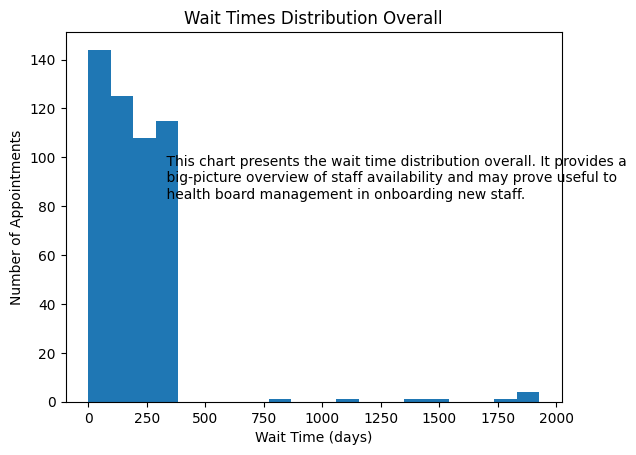

In [13]:
visualizer = Visualizer(outputDF)
visualizer.VisualizeWaitTimeDistributionOverall()

##### Fig. 2: Wait Time Distribution by Health Board (each board provided separately for readability)

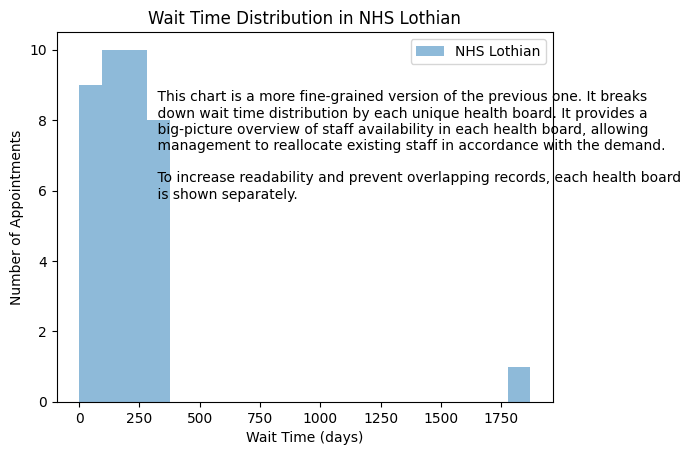

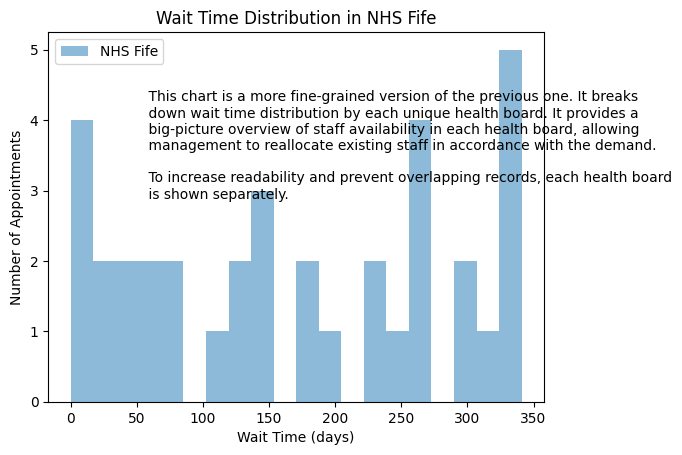

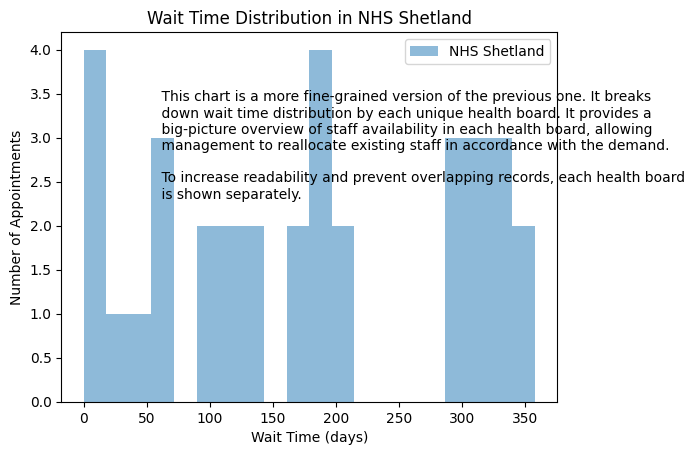

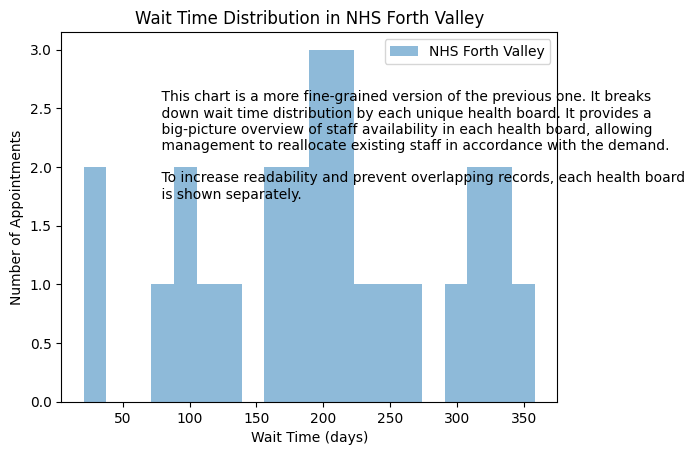

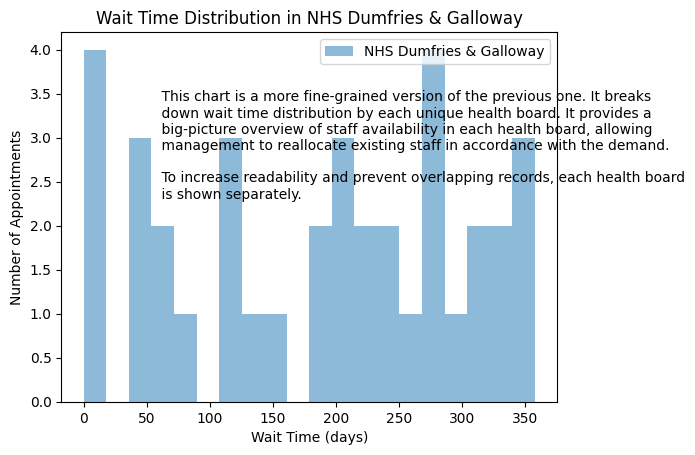

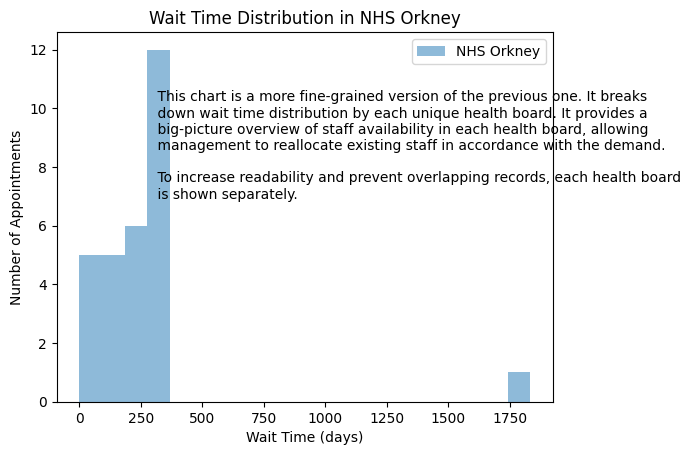

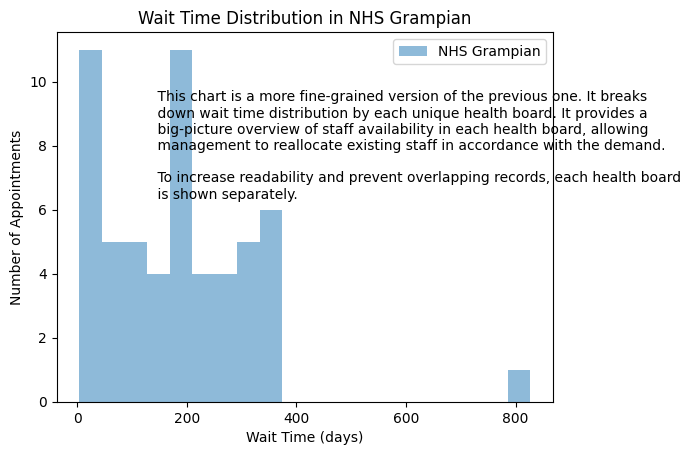

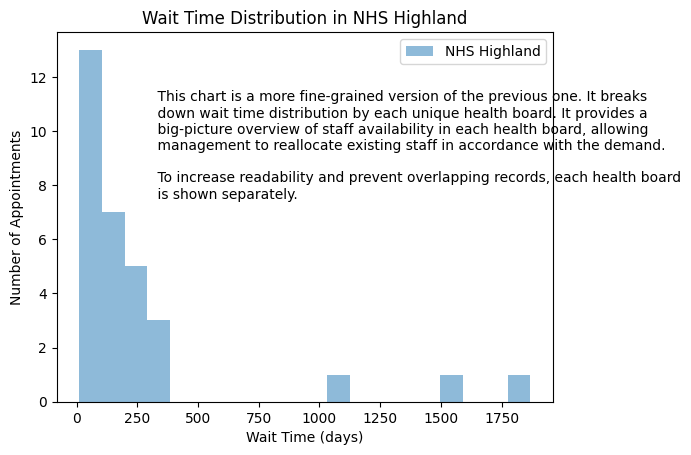

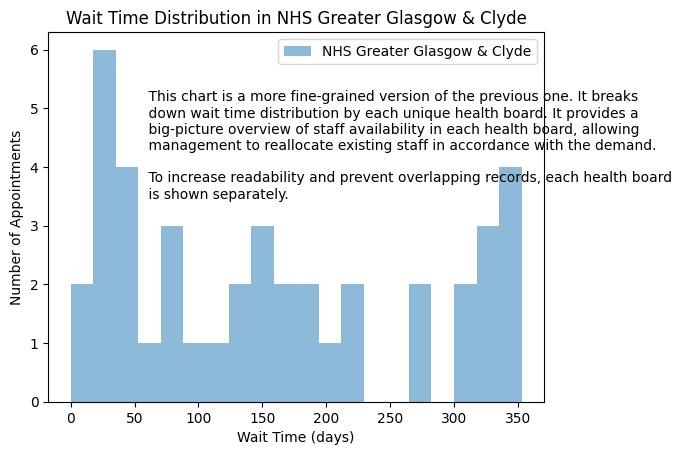

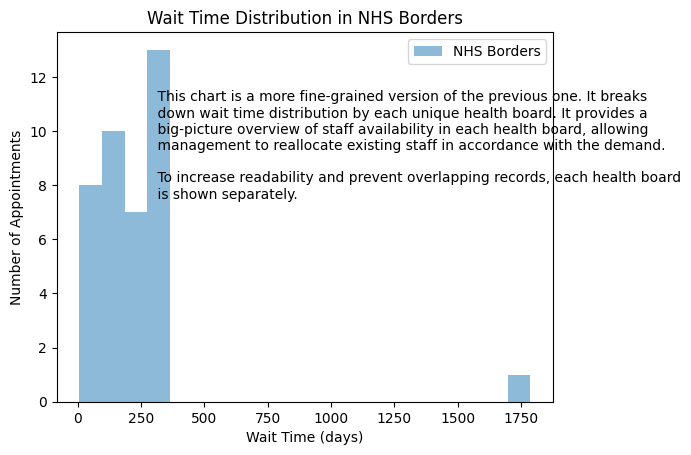

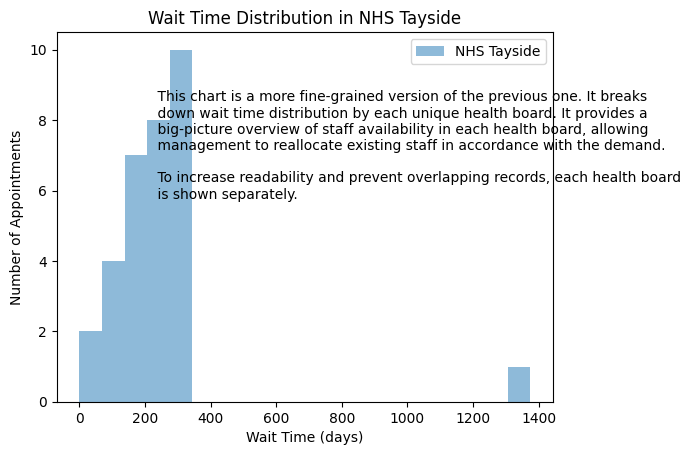

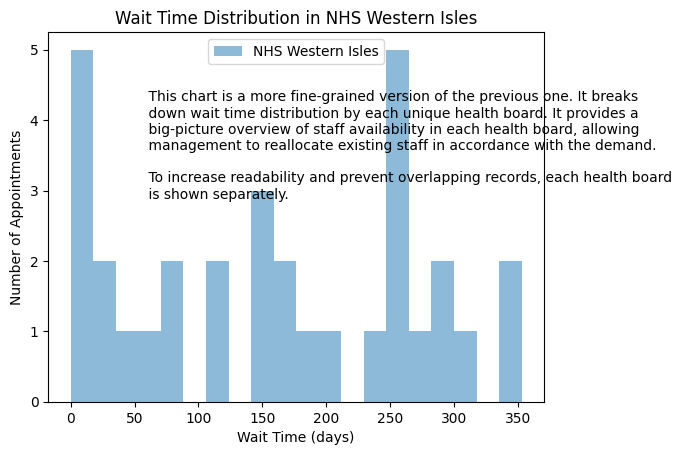

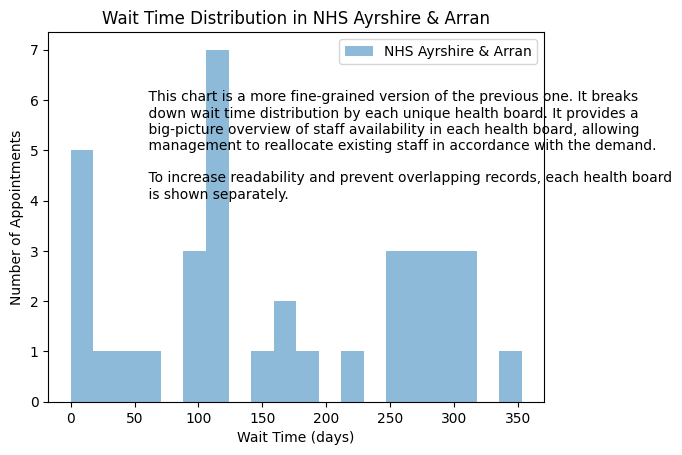

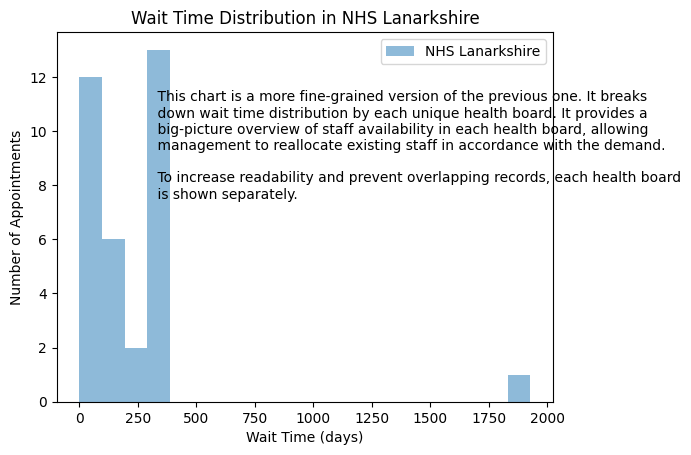

In [14]:
visualizer.VisualizeWaitTimeDistributionByBoard()

##### Fig. 3: DNA (Did not Attend) Rates by Health Board

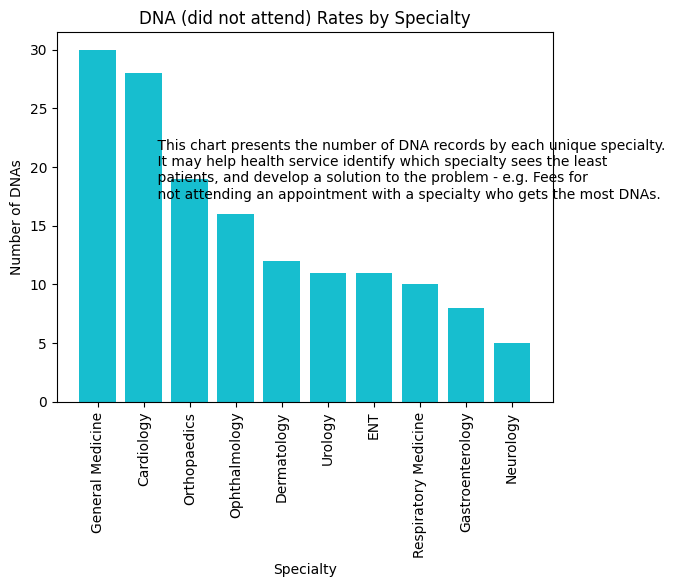

In [15]:
visualizer.VisualizeDnaRatesBySpecialty()

##### Fig. 4: Satisfaction Score Distribution by Specialty

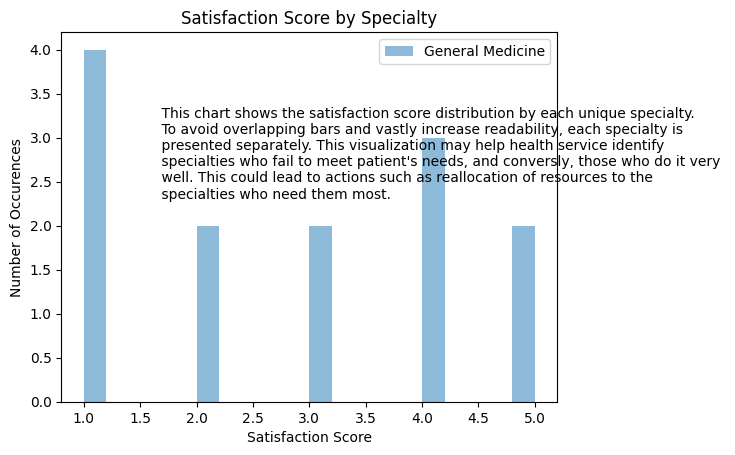

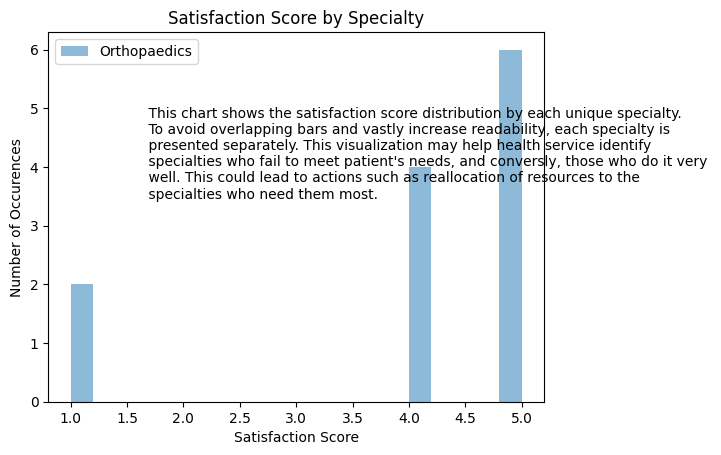

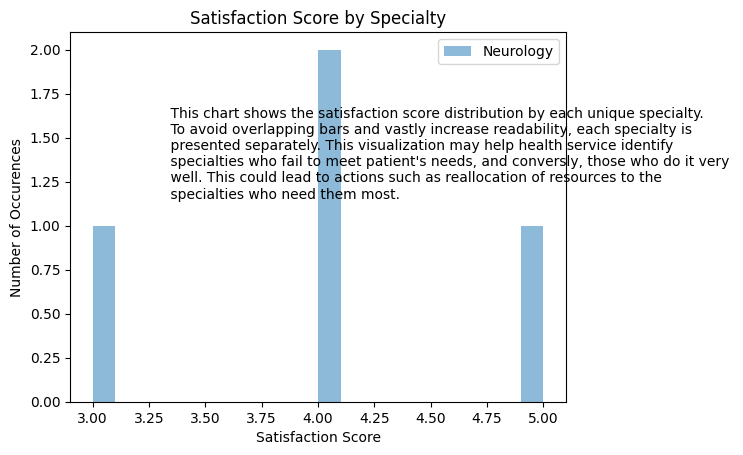

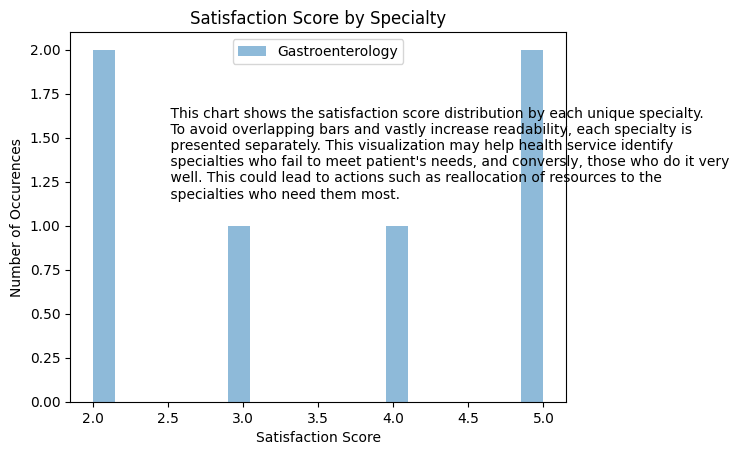

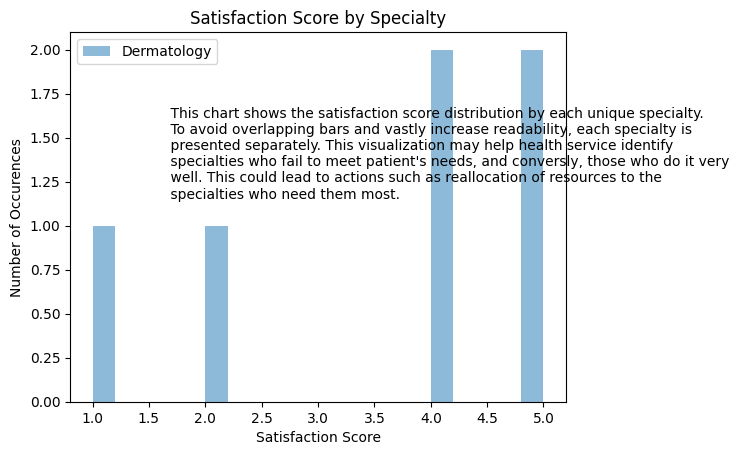

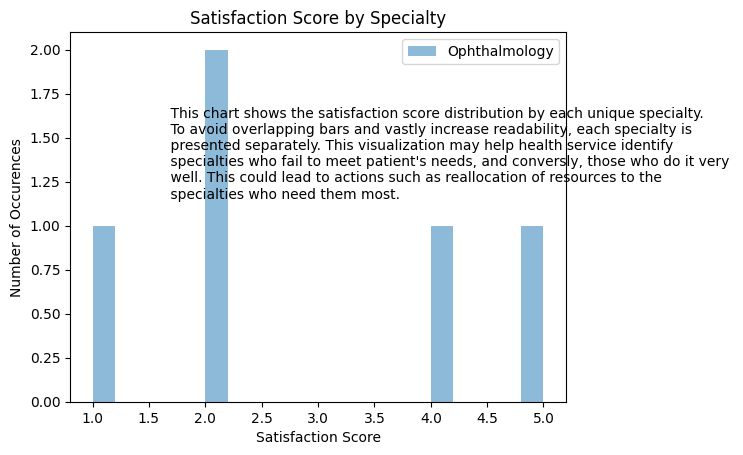

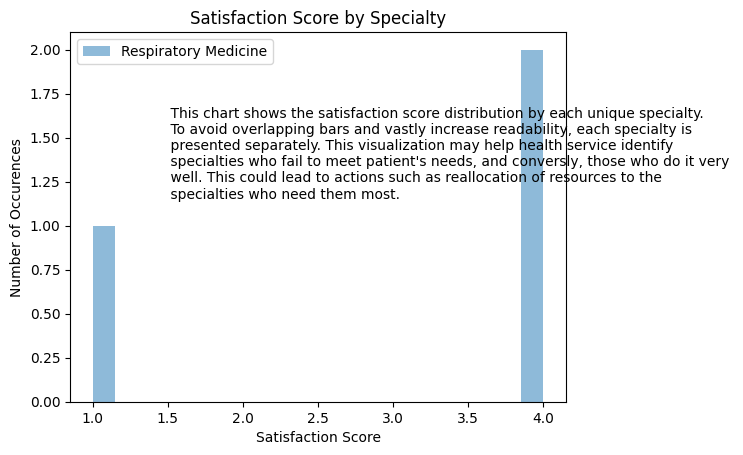

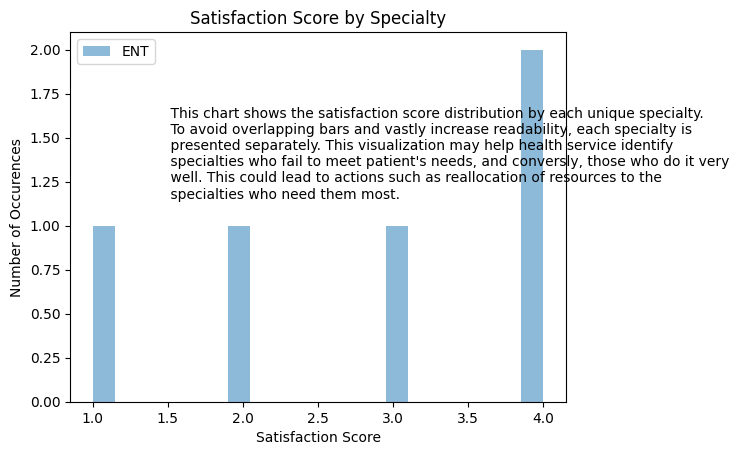

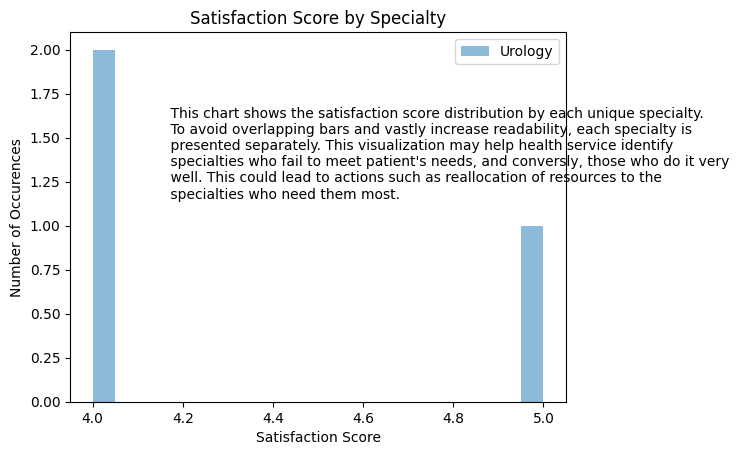

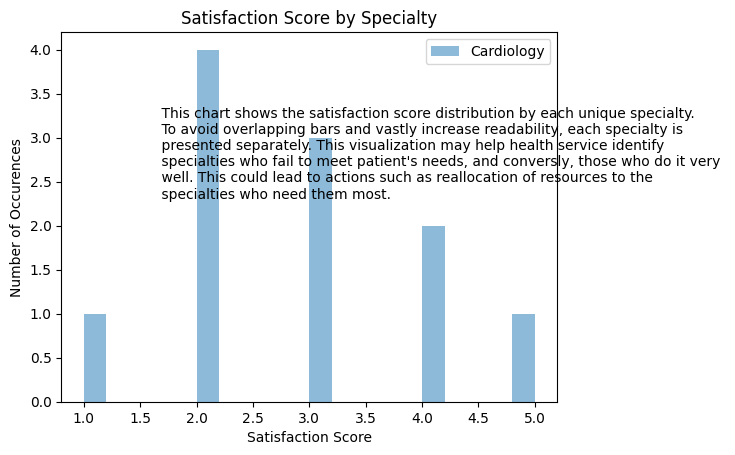

In [16]:
visualizer.VisualizeSatisfactionScoreDistributionBySpecialty()

##### Fig. 5: Relationship Between Wait Time and Consultation Duration

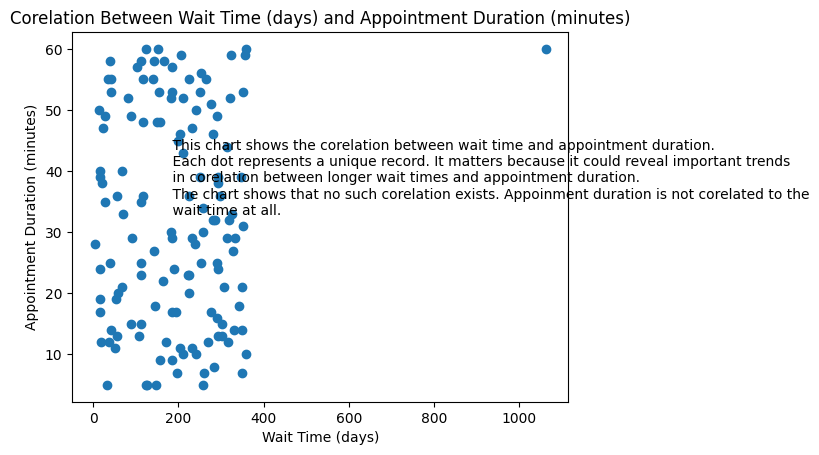

In [17]:
visualizer.VisualiseRelationshipBetweenWaitTimeAndConsultationDuration()

### Task 3: Statistical and Data Mining Analysis

#### 3(A)(1): Conditional probability related to appoinment attendance (P(DNA | wait time > 90 days) compared to P(DNA | wait time <= 90 days))

High attendence rates are crucial to 


In [18]:
totalOver = 0
dnasOver = 0

totalUnder = 0
dnasUnder = 0
for (_, rec) in outputDF.iterrows():
    if rec["Wait Time Days"] > 90:
        if rec["Outcome"] == "DNA":
            dnasOver += 1        
        totalOver += 1

    else:
        if rec["Outcome"] == "DNA":
            dnasUnder += 1
        totalUnder += 1

overProbability = 100 * (dnasOver / totalOver)
underProbability = 100 * (dnasUnder / totalUnder)
print(f"The probability of a patient not attending the appointment when wait time is over 90 days is {overProbability}%")
print(f"The probability of a patient not attending the appointment when wait time is equal to or under 90 days is {underProbability}%")


The probability of a patient not attending the appointment when wait time is over 90 days is 30.303030303030305%
The probability of a patient not attending the appointment when wait time is equal to or under 90 days is 28.985507246376812%


#### Interpretation
<table>
<tr>
    <th> Wait Time (Days) </th>
    <th> DNA Probability</th>
</tr>
<tr>
    <td> > 90 </td>
    <td> 30.3% </td>
</tr>
<tr>
    <td> <= 90 </td>
    <td> 28.9% </td>
</tr>
</table>

This analysis shows that the conditional probability of a patient not attending (DNA) when wait time exceeds 90 days is 30.3%, as compared to 28.9% when wait time is equal to or below 90 days. This shows that:

##### P(DNA | wait time > 90 days) > P(DNA | wait time <= 90 days)

indicating that longer wait times are associated with lower attendance rates. 

The difference in probabilities is about 2.4% which is relatively low, and not sufficient to show a clear causation. 

From a health care perspective, this indicates that reducing wait times under 90 days may help slightly improve attendance rates, but additional factors should also be carefully considered to meaningfully increase attendance rates.

#### 3(A)(3): Conditional Probability of Follow-up Requirement With Satisfaction Score of Less Than 3


In [19]:
totalRec = 0
followupReqRec = 0
for (_, rec) in outputDF.iterrows():
    if rec["Satisfaction Score"] < 3:
        totalRec += 1

        if rec["Follow Up Required"]:
            followupReqRec += 1

probability = 100 * (followupReqRec / totalRec)
print(f"The probability of a patient requiring a follow-up appointment when satisfaction score is less than 3 is {probability}%")

totalRec = 0
followupReqRec = 0
for (_, rec) in outputDF.iterrows():
    if rec["Satisfaction Score"] > 3:
        totalRec += 1

        if rec["Follow Up Required"]:
            followupReqRec += 1

probability = 100 * (followupReqRec / totalRec)
print(f"The probability of a patient requiring a follow-up appointment when satisfaction score is more than 3 is {probability}%")

The probability of a patient requiring a follow-up appointment when satisfaction score is less than 3 is 10.526315789473683%
The probability of a patient requiring a follow-up appointment when satisfaction score is more than 3 is 54.054054054054056%


#### Interpretation

<table>
<tr>
    <th> Satisfaction Score </th>
    <th> Follow-up Required Probability</th>
</tr>
<tr>
    <td> < 3 </td>
    <td> 10.5% </td>
</tr>
<tr>
    <td> > 3 </td>
    <td> 54% </td>
</tr>
</table>

This analysis shows that the conditional probability of a patient requiring a followup appointment when satisfaction score is less than three is 10.5%, compared to 54% when satisfaction score is more than three. This can be expressed as:

##### P(follow-up required | satisfaction score > 3) > P(follow-up required | satisfaction score < 3)

This indicates that higher satisfaction score is associated with a higher likelyhood of requiring a follow-up appointment.

One possible explanation for this is that patients who are more satisfied with the service are more inclined to engage with the service, accept suggested treatments, and book follow-up appointments. 

From a healthcare service perspective, this suggests that improving patient satisfaction may help increase engagement with the service, and consistency of care, which is important for treating complex conditions.

### 3(B)(A)
#### Null Hypothesis : There is no significant difference in mean wait times between NHS Highland and NHS Lothian.
#### Alternative Hypothesis: There is a significant difference in mean wait times between NHS Lothian and NHS Highland.

In [20]:
from scipy.stats import ttest_ind

lothianWaits = []
highlandWaits = []

for (_, rec) in outputDF.iterrows():
    if rec["Health Board"] == "NHS Lothian":
        lothianWaits.append(rec["Wait Time Days"])
    elif rec["Health Board"] == "NHS Highland":
        highlandWaits.append(rec["Wait Time Days"])

tStat, pVal = ttest_ind(lothianWaits, highlandWaits, equal_var=False)

print(f"T-statistic: {tStat}")
print(f"P-value: {pVal}")

T-statistic: -0.4378586946658586
P-value: 0.6633343925992573


#### Interpretation

An independent samples t-test was conducted to compare wait times between NHS Lothian and NHS Highland. The results are as follows:

##### T-Statistic: -0.4378586946658586
##### P-Value: 0.6633343925992573

Since P-Value is higher than 0.05, I failed to reject the null hypothesis,

This suggests that there is no evidence of statistically significant differences between wait times in NHS Lothian and NHS Highland,

From a healthcare service perspective, this suggests that there is no significant difference in wait times across the two locations. However this does not imply even distribution of staff and resources. More tests need to be conducted in order to determine resource distribution.

### Task 4: Insights and Recommendations

From the analyses conducted, the following three findings are the most important:

##### 1. General medicine has the highest DNA rates.
The costs of patients not attending appointments can be quite substantial. Apart from monetary losses, it renders other resources indispensable to other patients who may need it, as well as drives wait time up.
##### Recommended Action
To mitigate this issue, one potential solution would be for the Health board to penalize repeated offenders. This serves two goals; For one, it provides a material incentive for the patient to not miss their appointment, second, it helps offset the monetary losses suffered by the health board. There are two limitations to this solution; for one, the monetary losses will never realistically be fully compensated. Second, if a patient misses their appointment for a legitimate reason, it could prevent them from seeking urgent medical assistance, worsening their condition.
<br>
      
##### 2. Higher satisfaction score is associated with higher follow-up appointment requirements.
The data suggests that patients who report higher satisfaction are more likely to schedule follow-up appointments. This may indicate that greater satisfaction contributes to a higher level of engagement and a more continuous treatment.
##### Recommended Action
The health board should review whether follow-up appointments are being used effectively and consistently across specialties. Maintaining high patient satisfaction should remain a priority as it may support better engagement and health outcomes.
<br>

##### 3. There is no statistically significant corelation between wait times and appointment duration.
The analysis found no meaningful link between how long patients wait and how long their appointments last. This suggests that long waiting times are not caused by longer consultations, but likely by other factors such as demand, staffing levels, or scheduling inefficiencies.

##### Recommended action:
Efforts to reduce waiting times should focus on system-level improvements rather than shortening appointments. This could include reviewing staffing allocation, increasing capacity in high-demand areas, and improving scheduling systems to better match supply and demand.